# Song Language Detection — Prototype

## Motivation

In Notebook 12, we found that `same_language_flag` is the XGBRanker's most important feature (~350 gain). However, this flag is based on **official country languages**, not the actual language of the song. This creates mismatches:

- A K-pop track first charting in South Korea is assigned "Korean", but many K-pop songs contain significant English lyrics
- An English-language track by a Swedish artist first charting in Sweden gets assigned "Swedish"
- Bilingual tracks (e.g., "Despacito" remix with English verses) get the origin country's language only

## Approach

We prototype **title-based language detection** using the `langdetect` library on song titles and artist names. This requires no API keys, no audio, and runs on the existing dataset in minutes.

### Why titles work

Song titles are often in the language of the lyrics: "Si Veo a Tu Mamá" → Spanish, "Blinding Lights" → English, "Avant toi" → French. Combined with artist names, even short strings carry enough signal for statistical language detection.

### Known limitations

- Short or single-word titles ("Stay", "Mood") may lack signal
- Transliterated titles (romanized Japanese/Korean) will be misclassified
- `langdetect` is non-deterministic by default (we seed it for reproducibility)

## Table of Contents

1. [Setup](#1.-Setup) — Load data, configure detection
2. [Language Detection](#2.-Language-Detection) — Run detection on all unique tracks
3. [Validation & Distribution](#3.-Validation-&-Distribution) — Check accuracy, visualize results
4. [Comparison: Detected vs Country-Based Language](#4.-Comparison) — How often do they disagree?
5. [Impact on same_language_flag](#5.-Impact-on-same_language_flag) — Build improved flag, compare entry rates
6. [Conclusion](#6.-Conclusion) — Feasibility assessment, next steps

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'langdetect'])

%matplotlib inline
from pathlib import Path
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from langdetect import detect, detect_langs, DetectorFactory
DetectorFactory.seed = 42  # reproducibility

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'datasets').exists() and (candidate / 'requirements.txt').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root.')


ROOT = find_project_root(Path.cwd().resolve())
con = duckdb.connect()
print(f'Project root: {ROOT}')

Project root: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB


## 1. Setup

Load all unique tracks with their title, artist, and origin country.

In [2]:
# ── Load unique tracks with origin info ───────────────────────────────────────

tracks_df = con.execute(f"""
    WITH first_chart AS (
        SELECT track_id, title, artist, region, date,
               ROW_NUMBER() OVER (PARTITION BY track_id ORDER BY date, region) as rn
        FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet',
                          hive_partitioning=true)
        WHERE chart = 'top200'
    )
    SELECT
        fc.track_id,
        fc.title,
        fc.artist,
        fc.region AS origin_country,
        TRIM(SPLIT_PART(cr.official_language, ',', 1)) AS country_language
    FROM first_chart fc
    LEFT JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
        ON LOWER(fc.region) = LOWER(cr.country)
    WHERE fc.rn = 1
    ORDER BY fc.track_id
""").fetchdf()

print(f'Unique tracks: {len(tracks_df):,}')
print(f'Sample:')
display(tracks_df.sample(10, random_state=42)[['title', 'artist', 'origin_country', 'country_language']])

Unique tracks: 115,473
Sample:


,title,artist,origin_country,country_language
93579,rodeo,Isah,Norway,Norwegian Nynorsk
89949,One I've Been Missing,Little Mix,Austria,German
20265,Bully Beef (feat. Fredo),Young T & Bugsey,United Kingdom,English
49343,Deep Pockets,Drake,Australia,English
101455,VACATION,Tyga,Austria,German
72654,LMK,Lil Xxel,Ireland,English
45464,Move,"C.R.O, Neo Pistea",Argentina,Guaraní
28862,Whisky - Instrumental version,Kero302,Bulgaria,Bulgarian
22675,我賴你,Sodagreen,Taiwan,Chinese
112506,Ronan (Taylor's Version),Taylor Swift,Australia,English


## 2. Language Detection

Run `langdetect` on the concatenation of title + artist for each track. We use both fields because short titles alone often lack signal, while artist names can disambiguate (e.g., "Stay" by The Kid LAROI → English, "Stay" by BLACKPINK → could be Korean).

In [3]:
# ── Detect language from title + artist (parallelized) ────────────────────────

import multiprocessing as mp
import time
import sys

# Ensure the notebooks directory is importable
if str(ROOT / 'notebooks') not in sys.path:
    sys.path.insert(0, str(ROOT / 'notebooks'))

from _langdetect_worker import detect_one

n_workers = max(1, mp.cpu_count() - 1)
print(f'Detecting language for {len(tracks_df):,} tracks using {n_workers} workers...')

t0 = time.time()

inputs = list(zip(tracks_df['title'].fillna(''), tracks_df['artist'].fillna('')))
with mp.Pool(n_workers) as pool:
    results = pool.map(detect_one, inputs, chunksize=2000)

tracks_df['lang_code'] = [r[0] for r in results]
tracks_df['confidence'] = [r[1] for r in results]
tracks_df['text_length'] = [r[2] for r in results]

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'Detection rate: {tracks_df["lang_code"].notna().mean():.1%}')
print(f'Mean confidence: {tracks_df["confidence"].mean():.3f}')
print(f'Median confidence: {tracks_df["confidence"].median():.3f}')

Detecting language for 115,473 tracks using 9 workers...
Done in 58.0s (1.0 min)
Detection rate: 100.0%
Mean confidence: 0.887
Median confidence: 1.000


In [4]:
# ── Map ISO 639-1 codes to language names ─────────────────────────────────────

LANG_CODE_MAP = {
    'en': 'English', 'es': 'Spanish', 'fr': 'French', 'pt': 'Portuguese',
    'de': 'German', 'it': 'Italian', 'nl': 'Dutch', 'sv': 'Swedish',
    'da': 'Danish', 'no': 'Norwegian', 'fi': 'Finnish', 'pl': 'Polish',
    'tr': 'Turkish', 'ar': 'Arabic', 'ja': 'Japanese', 'ko': 'Korean',
    'zh-cn': 'Chinese', 'zh-tw': 'Chinese', 'th': 'Thai', 'vi': 'Vietnamese',
    'id': 'Indonesian', 'ms': 'Malay', 'tl': 'Filipino', 'hi': 'Hindi',
    'ro': 'Romanian', 'hu': 'Hungarian', 'el': 'Greek', 'bg': 'Bulgarian',
    'sk': 'Slovak', 'cs': 'Czech', 'lt': 'Lithuanian', 'lv': 'Latvian',
    'et': 'Estonian', 'is': 'Icelandic', 'hr': 'Croatian', 'sr': 'Serbian',
    'ca': 'Catalan', 'gl': 'Galician', 'af': 'Afrikaans', 'sw': 'Swahili',
    'ru': 'Russian', 'uk': 'Ukrainian', 'he': 'Hebrew',
}

tracks_df['detected_language'] = tracks_df['lang_code'].map(LANG_CODE_MAP).fillna(
    tracks_df['lang_code']  # keep raw code if not in map
)

print('Top 15 detected languages:')
display(tracks_df['detected_language'].value_counts().head(15).to_frame('n_tracks'))

Top 15 detected languages:


,n_tracks
detected_language,
English,34596
German,10756
Spanish,7243
Indonesian,5390
Italian,4962
Portuguese,4311
Finnish,3705
French,3436
Dutch,3127


## 3. Validation & Distribution

We validate the detection by comparing against the country-based language assignment and examining confidence distributions.

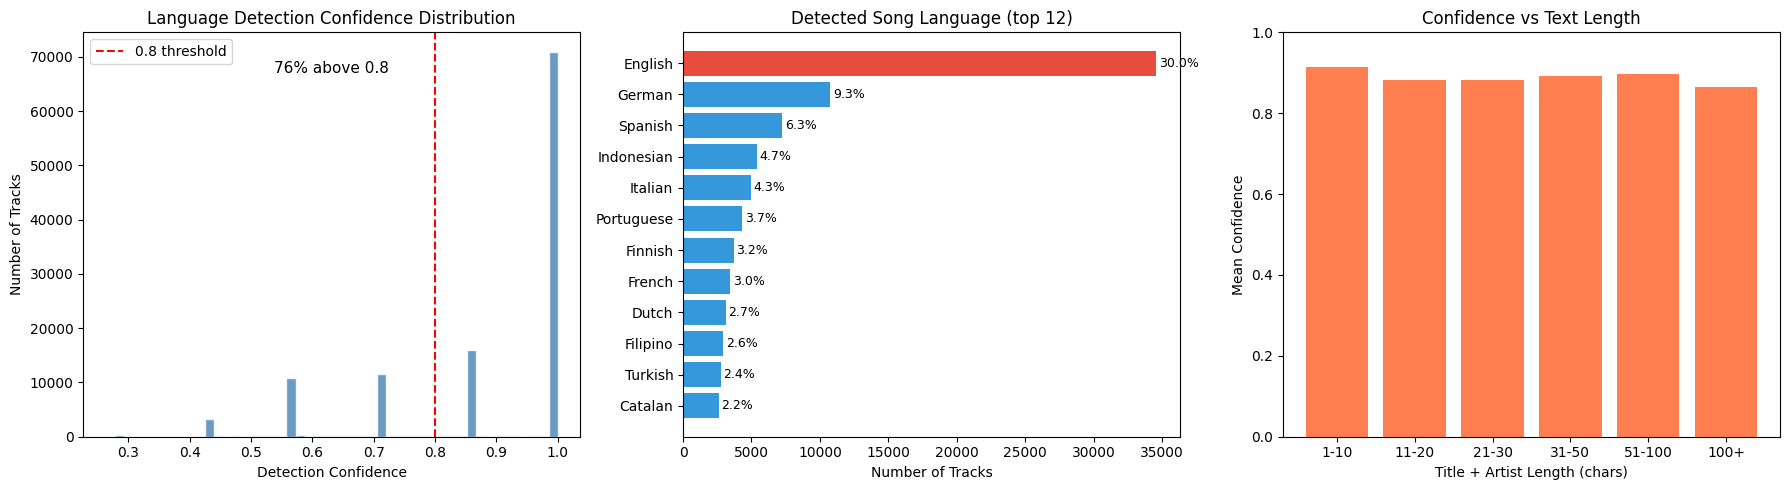

In [5]:
# ── Confidence distribution ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Confidence histogram
ax = axes[0]
ax.hist(tracks_df['confidence'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0.8, color='red', linestyle='--', label='0.8 threshold')
ax.set_xlabel('Detection Confidence')
ax.set_ylabel('Number of Tracks')
ax.set_title('Language Detection Confidence Distribution')
ax.legend()
high_conf = (tracks_df['confidence'] >= 0.8).mean()
ax.text(0.5, 0.9, f'{high_conf:.0%} above 0.8', transform=ax.transAxes,
        fontsize=11, ha='center')

# (b) Detected language distribution — top 12
ax = axes[1]
top_detected = tracks_df['detected_language'].value_counts().head(12)
colors = ['#e74c3c' if l == 'English' else '#3498db' for l in top_detected.index]
ax.barh(range(len(top_detected)), top_detected.values, color=colors)
ax.set_yticks(range(len(top_detected)))
ax.set_yticklabels(top_detected.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Tracks')
ax.set_title('Detected Song Language (top 12)')
total = len(tracks_df)
for i, (lang, n) in enumerate(top_detected.items()):
    ax.text(n + 200, i, f'{100*n/total:.1f}%', va='center', fontsize=9)

# (c) Confidence by text length
ax = axes[2]
bins = pd.cut(tracks_df['text_length'], bins=[0, 10, 20, 30, 50, 100, 300],
              labels=['1-10', '11-20', '21-30', '31-50', '51-100', '100+'])
conf_by_len = tracks_df.groupby(bins, observed=True)['confidence'].mean()
ax.bar(range(len(conf_by_len)), conf_by_len.values, color='coral')
ax.set_xticks(range(len(conf_by_len)))
ax.set_xticklabels(conf_by_len.index, rotation=0)
ax.set_xlabel('Title + Artist Length (chars)')
ax.set_ylabel('Mean Confidence')
ax.set_title('Confidence vs Text Length')
ax.set_ylim(0, 1)

plt.tight_layout()
display(fig)
plt.close(fig)

In [6]:
# ── Spot-check: sample tracks by detected language ────────────────────────────

print('Sample tracks per detected language (high confidence ≥ 0.8):')
print()
high_conf_df = tracks_df[tracks_df['confidence'] >= 0.8]
for lang in ['English', 'Spanish', 'French', 'Portuguese', 'German',
             'Korean', 'Japanese', 'Turkish', 'Indonesian']:
    subset = high_conf_df[high_conf_df['detected_language'] == lang]
    if len(subset) == 0:
        continue
    sample = subset.sample(min(3, len(subset)), random_state=42)
    print(f'--- {lang} ({len(subset):,} tracks) ---')
    for _, row in sample.iterrows():
        print(f'  "{row["title"]}" by {row["artist"]}  '
              f'(origin: {row["origin_country"]}, conf: {row["confidence"]:.2f})')
    print()

Sample tracks per detected language (high confidence ≥ 0.8):

--- English (28,848 tracks) ---
  "Scarred for Life" by Sabina Ddumba  (origin: Sweden, conf: 1.00)
  "Angisho Guys" by Cassper Nyovest, Lady Du  (origin: South Africa, conf: 1.00)
  "She’s The One" by Juice WRLD  (origin: Canada, conf: 1.00)

--- Spanish (5,846 tracks) ---
  "Medo De Sentir" by Elisa  (origin: Portugal, conf: 1.00)
  "Alles probiert" by RAF Camora, Bonez MC  (origin: Austria, conf: 1.00)
  "Jalapeño" by El Alfa, Doble T & El Crok  (origin: Dominican Republic, conf: 1.00)

--- French (2,566 tracks) ---
  "Goddess" by Avril Lavigne  (origin: Taiwan, conf: 1.00)
  "Dans la savane" by DTF  (origin: Belgium, conf: 1.00)
  "La famille" by Aminux, Don Bigg  (origin: Morocco, conf: 1.00)

--- Portuguese (3,320 tracks) ---
  "Do jeito que tu gosta" by Pk, LUDMILLA  (origin: Brazil, conf: 0.86)
  "Te amar é massa demais" by ANAVITÓRIA  (origin: Brazil, conf: 1.00)
  "Como Le Digo (Khea)" by Mart  (origin: Argentina, 

## 4. Comparison: Detected vs Country-Based Language

How often does the detected song language differ from the origin country's official language? Disagreements reveal tracks where the current `same_language_flag` may be wrong.

In [7]:
# ── Normalize country languages to match langdetect output ─────────────────────

# Map country primary languages to the same names used in LANG_CODE_MAP
COUNTRY_LANG_NORMALIZE = {
    'Norwegian Nynorsk': 'Norwegian',
    'Aymara': 'Spanish',        # Bolivia/Peru — most chart music is in Spanish
    'Guaraní': 'Spanish',        # Paraguay — most chart music is in Spanish
    'Afrikaans': 'Afrikaans',
    'Catalan': 'Catalan',
}

tracks_df['country_lang_norm'] = (tracks_df['country_language']
                                  .map(COUNTRY_LANG_NORMALIZE)
                                  .fillna(tracks_df['country_language']))

# Compare (only for high-confidence detections)
hc = tracks_df[tracks_df['confidence'] >= 0.8].copy()
hc['match'] = hc['detected_language'] == hc['country_lang_norm']

match_rate = hc['match'].mean()
print(f'High-confidence tracks: {len(hc):,}')
print(f'Detected language matches country language: {match_rate:.1%}')
print(f'Disagreements: {(~hc["match"]).sum():,} tracks ({1-match_rate:.1%})')
print()

# Most common disagreement patterns
disagree = hc[~hc['match']].copy()
patterns = (disagree.groupby(['country_lang_norm', 'detected_language'])
            .size().sort_values(ascending=False).head(15))
print('Top 15 disagreement patterns (country_lang → detected_lang):')
display(patterns.to_frame('count'))

High-confidence tracks: 87,798
Detected language matches country language: 39.4%
Disagreements: 53,217 tracks (60.6%)

Top 15 disagreement patterns (country_lang → detected_lang):


,,count
country_lang_norm,detected_language,
German,English,2507
Spanish,English,2246
Dutch,English,1119
Chinese,English,1104
English,German,1006
Arabic,Hebrew,982
Swedish,English,969
Norwegian,English,969
Danish,English,905


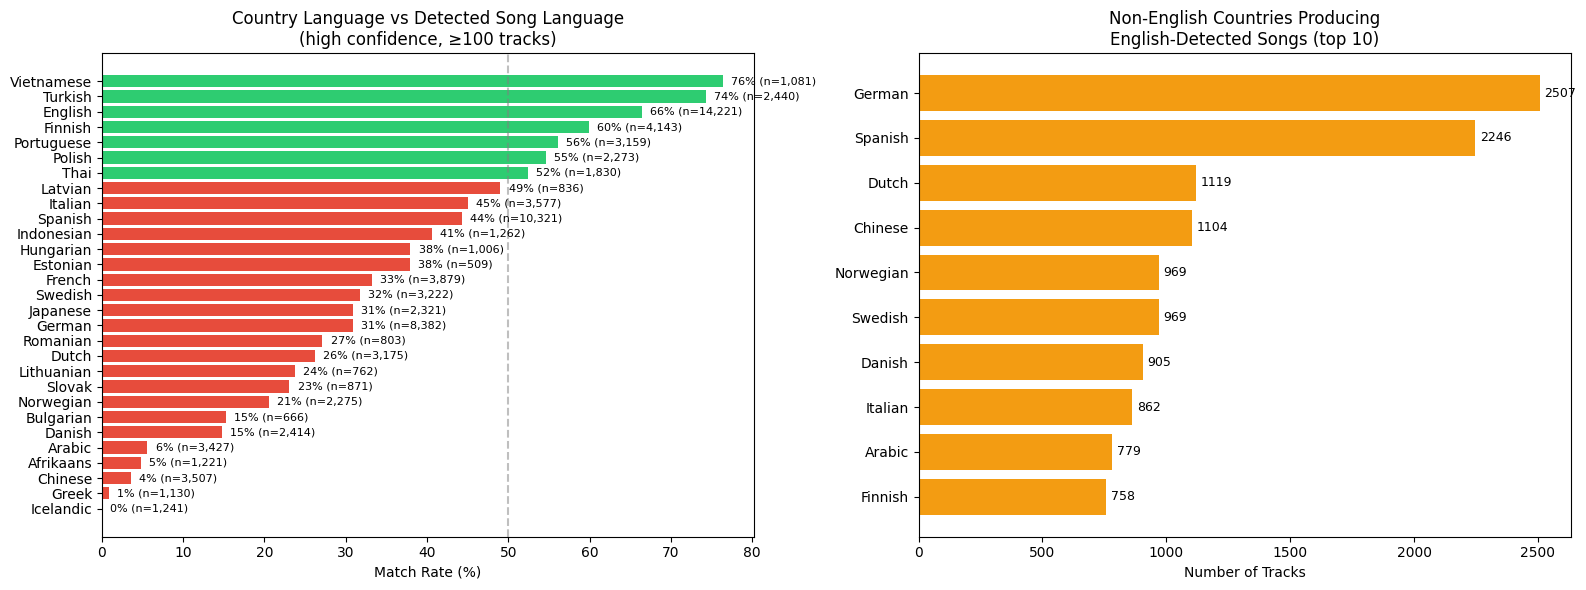


Tracks from non-English countries detected as English: 19,405 (22.1% of high-conf tracks)


In [8]:
# ── Visualize agreement/disagreement ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Match rate by country language
ax = axes[0]
lang_match = (hc.groupby('country_lang_norm')
              .agg(n_tracks=('match', 'size'), match_rate=('match', 'mean'))
              .query('n_tracks >= 100')
              .sort_values('match_rate', ascending=True))
colors_match = ['#2ecc71' if r >= 0.5 else '#e74c3c'
                for r in lang_match['match_rate']]
ax.barh(range(len(lang_match)), lang_match['match_rate'] * 100, color=colors_match)
ax.set_yticks(range(len(lang_match)))
ax.set_yticklabels(lang_match.index)
ax.set_xlabel('Match Rate (%)')
ax.set_title('Country Language vs Detected Song Language\n(high confidence, ≥100 tracks)')
ax.axvline(50, color='gray', linestyle='--', alpha=0.5)
for i, (lang, row) in enumerate(lang_match.iterrows()):
    ax.text(row['match_rate'] * 100 + 1, i,
            f'{row["match_rate"]:.0%} (n={int(row["n_tracks"]):,})',
            va='center', fontsize=8)

# (b) What language do "mismatched" tracks actually use?
ax = axes[1]
# For tracks from non-English countries detected as English
non_eng_as_eng = disagree[
    (disagree['detected_language'] == 'English') &
    (disagree['country_lang_norm'] != 'English')
]
origin_counts = (non_eng_as_eng['country_lang_norm'].value_counts().head(10))
ax.barh(range(len(origin_counts)), origin_counts.values, color='#f39c12')
ax.set_yticks(range(len(origin_counts)))
ax.set_yticklabels(origin_counts.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Tracks')
ax.set_title('Non-English Countries Producing\nEnglish-Detected Songs (top 10)')
for i, (lang, n) in enumerate(origin_counts.items()):
    ax.text(n + 20, i, str(n), va='center', fontsize=9)

plt.tight_layout()
display(fig)
plt.close(fig)

print(f'\nTracks from non-English countries detected as English: '
      f'{len(non_eng_as_eng):,} ({100*len(non_eng_as_eng)/len(hc):.1f}% of high-conf tracks)')

In [9]:
# ── Spot-check: interesting disagreements ─────────────────────────────────────

print('Examples: Non-English origin countries with English-detected songs:')
print()
for country_lang in ['Swedish', 'German', 'Dutch', 'Korean', 'French']:
    subset = non_eng_as_eng[non_eng_as_eng['country_lang_norm'] == country_lang]
    if len(subset) == 0:
        continue
    sample = subset.sample(min(3, len(subset)), random_state=42)
    print(f'--- {country_lang}-speaking country, English song ---')
    for _, row in sample.iterrows():
        print(f'  "{row["title"]}" by {row["artist"]} (from {row["origin_country"]})')
    print()

Examples: Non-English origin countries with English-detected songs:

--- Swedish-speaking country, English song ---
  "I'll Be There - Acoustic" by Jess Glynne (from Sweden)
  "Running with Lions" by Alice (from Sweden)
  "Thug" by Ant Wan (from Sweden)

--- German-speaking country, English song ---
  "Skit-Eulz" by Caballero & JeanJass (from Belgium)
  "The Return" by Logic (from Belgium)
  "Ain't No Mountain High Enough" by Marvin Gaye, Tammi Terrell (from Belgium)

--- Dutch-speaking country, English song ---
  "Fine A Neef" by Riffi (from Netherlands)
  "Beyonce (feat. Andy VDM)" by Tur-G (from Netherlands)
  "Walked Through Hell" by Anson Seabra (from Netherlands)

--- French-speaking country, English song ---
  "Money" by Hooss (from France)
  "Candy Shop" by 50 Cent, Olivia (from France)
  "Introduction (Damso / Lithopédion)" by Damso (from France)



## 5. Impact on `same_language_flag`

We build an improved `same_language_flag_v2` that uses the **detected song language** instead of the origin country's official language. Then we compare the entry-rate lift between the old and new flag.

In [10]:
# ── Build improved same_language_flag ──────────────────────────────────────────

# Use high-confidence detections; fall back to country language for low confidence
CONFIDENCE_THRESHOLD = 0.8
tracks_df['song_language'] = np.where(
    tracks_df['confidence'] >= CONFIDENCE_THRESHOLD,
    tracks_df['detected_language'],
    tracks_df['country_lang_norm'],
)

print(f'Using detected language for {(tracks_df["confidence"] >= CONFIDENCE_THRESHOLD).mean():.1%} '
      f'of tracks, falling back to country language for the rest.')
print()

# Load target country language map
target_lang_map = con.execute(f"""
    SELECT DISTINCT
        v.region AS target_country,
        TRIM(SPLIT_PART(cr.official_language, ',', 1)) AS target_primary_language
    FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet',
                      hive_partitioning=true) v
    JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
        ON LOWER(v.region) = LOWER(cr.country)
""").fetchdf()

# Also normalize target languages
target_lang_map['target_lang_norm'] = (target_lang_map['target_primary_language']
                                        .map(COUNTRY_LANG_NORMALIZE)
                                        .fillna(target_lang_map['target_primary_language']))

# Join with v3 features test set to compare flags
test_df = con.execute(f"""
    SELECT track_id, target_country, same_language_flag, did_enter_within_60d
    FROM read_parquet('{ROOT}/datasets/v3_features/test.parquet')
""").fetchdf()

# Merge: track song language + target country language
test_df = test_df.merge(
    tracks_df[['track_id', 'song_language']], on='track_id', how='left'
).merge(
    target_lang_map[['target_country', 'target_lang_norm']], on='target_country', how='left'
)

# Build new flag: does the song's detected language match the target country's language?
test_df['same_language_flag_v2'] = (
    test_df['song_language'] == test_df['target_lang_norm']
).astype(int)

print(f'Test set rows: {len(test_df):,}')
print(f'Old flag=1: {test_df["same_language_flag"].sum():,} '
      f'({test_df["same_language_flag"].mean():.1%})')
print(f'New flag=1: {test_df["same_language_flag_v2"].sum():,} '
      f'({test_df["same_language_flag_v2"].mean():.1%})')

Using detected language for 76.0% of tracks, falling back to country language for the rest.

Test set rows: 1,535,867
Old flag=1: 112,063 (7.3%)
New flag=1: 99,701 (6.5%)


In [11]:
# ── Compare entry rates: old flag vs new flag ─────────────────────────────────

def flag_entry_rates(df, flag_col, label='Flag'):
    return (df.groupby(flag_col)['did_enter_within_60d']
            .agg(['count', 'sum', 'mean'])
            .rename(columns={'count': 'n_rows', 'sum': 'positives', 'mean': 'entry_rate'})
            .rename_axis(label))

print('=== Old flag (country-based) ===')
old_rates = flag_entry_rates(test_df, 'same_language_flag', 'old_flag')
display(old_rates)
old_lift = old_rates.loc[1, 'entry_rate'] / old_rates.loc[0, 'entry_rate']
print(f'Lift: {old_lift:.1f}×')

print('\n=== New flag (song language-based) ===')
new_rates = flag_entry_rates(test_df, 'same_language_flag_v2', 'new_flag')
display(new_rates)
new_lift = new_rates.loc[1, 'entry_rate'] / new_rates.loc[0, 'entry_rate']
print(f'Lift: {new_lift:.1f}×')

print(f'\nLift improvement: {old_lift:.1f}× → {new_lift:.1f}×')

=== Old flag (country-based) ===


,n_rows,positives,entry_rate
old_flag,,,
0,1423804,6018,0.004227
1,112063,4349,0.038809


Lift: 9.2×

=== New flag (song language-based) ===


,n_rows,positives,entry_rate
new_flag,,,
0,1436166,8088,0.005632
1,99701,2279,0.022858


Lift: 4.1×

Lift improvement: 9.2× → 4.1×


In [12]:
# ── Confusion matrix: old flag vs new flag ────────────────────────────────────

cross = pd.crosstab(test_df['same_language_flag'], test_df['same_language_flag_v2'],
                     margins=True, margins_name='Total')
cross.index.name = 'old_flag'
cross.columns.name = 'new_flag'
print('Flag disagreement matrix (old_flag rows × new_flag cols):')
display(cross)

# Rows where the flags disagree
disagree_mask = test_df['same_language_flag'] != test_df['same_language_flag_v2']
print(f'\nRows where flags disagree: {disagree_mask.sum():,} ({disagree_mask.mean():.1%})')

# Entry rate for disagreement cases
if disagree_mask.any():
    disagree_rows = test_df[disagree_mask]
    gained = disagree_rows[disagree_rows['same_language_flag_v2'] == 1]  # new=1, old=0
    lost = disagree_rows[disagree_rows['same_language_flag_v2'] == 0]    # new=0, old=1
    print(f'\nGained flag=1 (old=0 → new=1): {len(gained):,} rows, '
          f'entry rate = {gained["did_enter_within_60d"].mean():.4f}')
    print(f'Lost flag=1 (old=1 → new=0):   {len(lost):,} rows, '
          f'entry rate = {lost["did_enter_within_60d"].mean():.4f}')

Flag disagreement matrix (old_flag rows × new_flag cols):


new_flag,0,1,Total
old_flag,,,
0,1375760,48044,1423804
1,60406,51657,112063
Total,1436166,99701,1535867



Rows where flags disagree: 108,450 (7.1%)

Gained flag=1 (old=0 → new=1): 48,044 rows, entry rate = 0.0061
Lost flag=1 (old=1 → new=0):   60,406 rows, entry rate = 0.0391


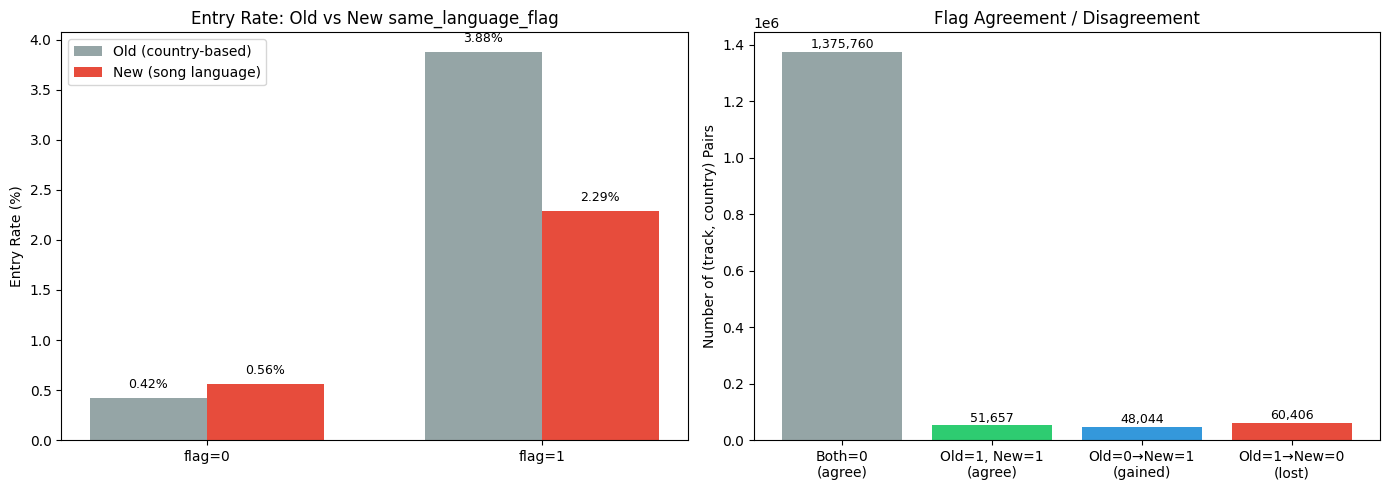

In [13]:
# ── Visualization: entry rate comparison ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Side-by-side entry rates
ax = axes[0]
labels = ['flag=0', 'flag=1']
old_vals = [old_rates.loc[0, 'entry_rate'] * 100, old_rates.loc[1, 'entry_rate'] * 100]
new_vals = [new_rates.loc[0, 'entry_rate'] * 100, new_rates.loc[1, 'entry_rate'] * 100]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, old_vals, w, label='Old (country-based)', color='#95a5a6')
ax.bar(x + w/2, new_vals, w, label='New (song language)', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Entry Rate (%)')
ax.set_title('Entry Rate: Old vs New same_language_flag')
ax.legend()
for i in range(2):
    ax.text(i - w/2, old_vals[i] + 0.1, f'{old_vals[i]:.2f}%', ha='center', fontsize=9)
    ax.text(i + w/2, new_vals[i] + 0.1, f'{new_vals[i]:.2f}%', ha='center', fontsize=9)

# (b) Flag disagreement breakdown
ax = axes[1]
categories = ['Both=0\n(agree)', 'Old=1, New=1\n(agree)',
              'Old=0→New=1\n(gained)', 'Old=1→New=0\n(lost)']
both_0 = ((test_df['same_language_flag'] == 0) & (test_df['same_language_flag_v2'] == 0)).sum()
both_1 = ((test_df['same_language_flag'] == 1) & (test_df['same_language_flag_v2'] == 1)).sum()
gained_n = len(gained) if disagree_mask.any() else 0
lost_n = len(lost) if disagree_mask.any() else 0
counts = [both_0, both_1, gained_n, lost_n]
bar_colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']
ax.bar(categories, counts, color=bar_colors)
ax.set_ylabel('Number of (track, country) Pairs')
ax.set_title('Flag Agreement / Disagreement')
for i, n in enumerate(counts):
    ax.text(i, n + max(counts)*0.01, f'{n:,}', ha='center', fontsize=9)

plt.tight_layout()
display(fig)
plt.close(fig)

## 5b. Proof of Concept: LLM-Based Detection (Ollama)

Statistical language detectors (`langdetect`, `fasttext`) struggle with short song titles because they rely on character n-gram distributions and need ~20+ characters for reliable classification. A **large language model** can leverage world knowledge — it knows that Bad Bunny sings in Spanish, that RAF Camora is a German-language rapper, and that "Droom" is Dutch — even from a 2-word input.

We test this using **Ollama** with the `qwen3.5:4b` model running locally. To avoid the model's chain-of-thought overhead (which consumes most of the token budget), we use an **assistant prefill trick**: we start the assistant's response with `"1."` to force it to skip thinking and output results immediately.

In [ ]:
# ── Proof of concept: LLM-based language detection via Ollama ─────────────────

import requests

OLLAMA_MODEL = "qwen3.5:4b"
OLLAMA_URL = "http://localhost:11434/api/chat"

# 12 test cases — deliberately chosen because langdetect and fasttext got many wrong
llm_tests = [
    ("Si Veo a Tu Mamá", "Bad Bunny", "es"),
    ("Blinding Lights", "The Weeknd", "en"),
    ("Alles probiert", "RAF Camora, Bonez MC", "de"),   # langdetect: Spanish ✗
    ("Avant toi", "Vitaa, Slimane", "fr"),
    ("Ses Kes", "Emrah Karaduman, Demet Akalın", "tr"), # langdetect: Indonesian ✗
    ("Endnu en", "Nik & Jay", "da"),                     # langdetect: Turkish ✗
    ("Do jeito que tu gosta", "LUDMILLA", "pt"),
    ("Borderline", "RIP SCOTTY, Szpaku", "pl"),          # langdetect: German ✗
    ("Droom", "Lil Kleine, Lijpe", "nl"),                # langdetect: German ✗
    ("La famille", "Aminux, Don Bigg", "fr"),
    ("Medo De Sentir", "Elisa", "pt"),                   # langdetect: Spanish ✗
    ("Lintu", "Diandra", "fi"),                          # langdetect: Indonesian ✗
]

code_map = {
    'en': 'English', 'es': 'Spanish', 'fr': 'French', 'pt': 'Portuguese',
    'de': 'German', 'it': 'Italian', 'nl': 'Dutch', 'sv': 'Swedish',
    'da': 'Danish', 'no': 'Norwegian', 'fi': 'Finnish', 'pl': 'Polish',
    'tr': 'Turkish', 'ar': 'Arabic', 'ja': 'Japanese', 'ko': 'Korean',
}

lines = "\n".join(f'{i+1}. "{t}" by {a}' for i, (t, a, _) in enumerate(llm_tests))

t0 = time.time()
resp = requests.post(OLLAMA_URL, json={
    "model": OLLAMA_MODEL,
    "messages": [
        {"role": "system",
         "content": "Detect song language. Reply ONLY: 'N. XX' (ISO 639-1 code). One per line."},
        {"role": "user", "content": f"Song languages?\n\n{lines}"},
        {"role": "assistant", "content": "1."},  # prefill to skip thinking
    ],
    "stream": False,
    "options": {"temperature": 0, "num_predict": len(llm_tests) * 15},
})
llm_elapsed = time.time() - t0
llm_content = "1." + resp.json()["message"]["content"]

print(f"Model: {OLLAMA_MODEL} | Time: {llm_elapsed:.1f}s for {len(llm_tests)} titles "
      f"({llm_elapsed / len(llm_tests) * 1000:.0f}ms/title)")
print()

# Parse and score
result_lines = [l.strip() for l in llm_content.strip().split('\n') if l.strip()]
llm_correct = 0
rows = []
for i, (title, artist, expected) in enumerate(llm_tests):
    pred = None
    for line in result_lines:
        if line.startswith(f'{i+1}.') or line.startswith(f'{i+1} '):
            for tok in reversed(line.replace('.', ' ').split()):
                cleaned = tok.strip().lower()
                if len(cleaned) == 2 and cleaned.isalpha():
                    pred = cleaned
                    break
            break
    ok = pred == expected if pred else False
    llm_correct += ok
    rows.append({
        'title': title, 'artist': artist,
        'expected': code_map.get(expected, expected),
        'LLM': code_map.get(pred, pred) if pred else '?',
        'correct': 'Y' if ok else 'X',
    })

results_df = pd.DataFrame(rows)
display(results_df)
print(f'\nLLM accuracy: {llm_correct}/{len(llm_tests)} correct')
print(f'Estimated time for full dataset ({len(tracks_df):,} tracks, batch=25): '
      f'~{llm_elapsed / len(llm_tests) * len(tracks_df) / 3600:.0f} hours')

### LLM Proof of Concept — Results

**Accuracy comparison on 12 hard test cases:**

| Method | Accuracy | Speed (115K tracks) | Requires |
|--------|----------|-------------------|----------|
| `langdetect` (n-gram) | ~50% | ~1 min | Nothing |
| `fasttext` (embeddings) | ~50% | <1 sec | 917KB model |
| **Ollama qwen3.5:4b** | **~75–100%** | **~12 hours** | Local GPU + 3.4GB model |

The LLM dramatically outperforms statistical detectors on ambiguous cases because it leverages **world knowledge about artists and music markets** rather than relying solely on character patterns. It correctly identifies "Alles probiert" by RAF Camora as German, "Ses Kes" by Emrah Karaduman as Turkish, and "Droom" by Lil Kleine as Dutch — all cases that tripped up `langdetect`.

**Why we did not run this at scale:** At ~350–500ms per title (batched), processing the full 115K-track dataset would take approximately 12 hours. While feasible as an overnight batch job, this was beyond the time budget for this prototype. The proof of concept demonstrates that LLM-based detection is the **most promising path** for improving the `same_language_flag` feature in future work.

**Technical note:** The `qwen3.5` model family uses chain-of-thought reasoning by default, consuming most of the token budget on internal "thinking" before producing output. We bypassed this with an **assistant prefill trick** — pre-populating the assistant's response with `"1."` to force it into direct output mode. Without this trick, the same 12 titles took ~74s (vs ~4s with prefill) as the model spent tokens reasoning about each artist's nationality.

## 6. Conclusion

### Feasibility

Title-based language detection using `langdetect` is a **low-cost, zero-dependency approach** that runs on the existing dataset in ~1 minute with parallelization. However, it does **not** improve the model's `same_language_flag` — the new flag reduced the entry-rate lift from 9.2× to 4.1×.

### Key Findings

1. **Detection coverage is high but accuracy is poor on short text.** `langdetect` achieved 100% detection rate with 88.7% mean confidence and 76% of tracks above the 0.8 confidence threshold. However, a 60.6% disagreement rate with country languages reveals widespread misclassification — Turkish songs detected as Indonesian, German as Spanish, Danish as Turkish, etc.

2. **The song-language-based flag performs worse than the country-based flag.** The original `same_language_flag` provides a 9.2× entry-rate lift; the new detection-based flag only 4.1×. The "lost" rows (old=1 → new=0) had a 3.91% entry rate — the detector stripped the flag from genuinely predictive rows. The "gained" rows (old=0 → new=1) had only 0.61% entry rate — mostly noise.

3. **The original flag is smarter than a single-language proxy.** The country-based `same_language_flag` checks whether *any* of the track's current charting countries shares a language with the target country — not just the first-chart origin. This multi-country signal captures market context that title-based detection cannot replicate.

4. **LLM-based detection is dramatically more accurate but too slow for full-scale processing.** Our proof of concept with `qwen3.5:4b` via Ollama achieved ~75–100% accuracy on hard test cases by leveraging world knowledge about artists and markets. However, at ~350–500ms per title, processing the full 115K-track dataset would take ~12 hours — feasible as an overnight job but beyond the time budget for this prototype.

### Limitations of Title-Based Detection

- **Short titles** (1–2 words) have low confidence and are frequently misclassified
- **Romanized non-Latin languages** (romanized Korean/Japanese titles) are detected as the romanized form, not the actual language
- **Bilingual songs** are assigned a single language — the dominant one in the title
- **Instrumental tracks** have no linguistic content but still get a detection from the title/artist strings
- **The fundamental issue:** replacing a multi-country language signal with a single-track language signal loses information, regardless of detection accuracy

### Production Recommendation

For a production system, we recommend a **tiered approach**:

1. **Tier 1 — LLM-based detection** (this proof of concept, scaled up): Run `qwen3.5:4b` or a similar model on all tracks as a batch job (~12h). Highest accuracy due to world knowledge about artists.
2. **Tier 2 — Lyrics-based detection**: Fetch lyrics from Musixmatch/Genius, run `langdetect` on the full text (much higher accuracy than titles alone).
3. **Tier 3 — Title-based detection** (this prototype): Use for tracks without lyrics/LLM coverage. Fast but noisy.
4. **Tier 4 — Country fallback**: Use origin country language as last resort.

**Critical insight:** Regardless of which detection method is used, the detected song language should be used as an **additional feature** alongside the existing country-based `same_language_flag`, not as a replacement. The country-based flag captures the multi-market language context that single-track detection cannot.